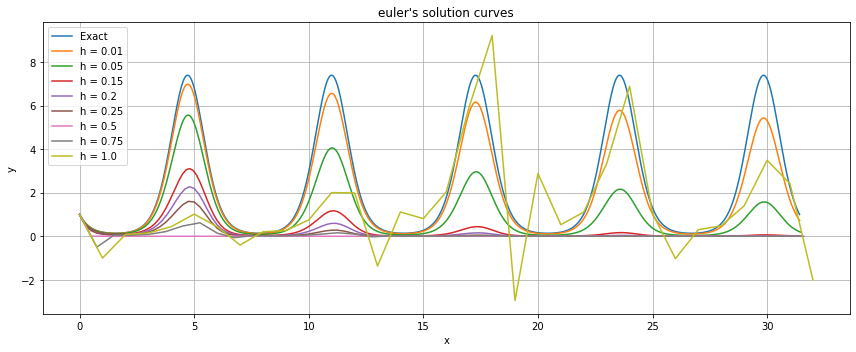

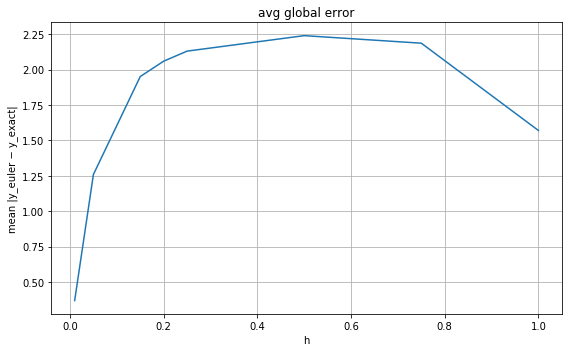

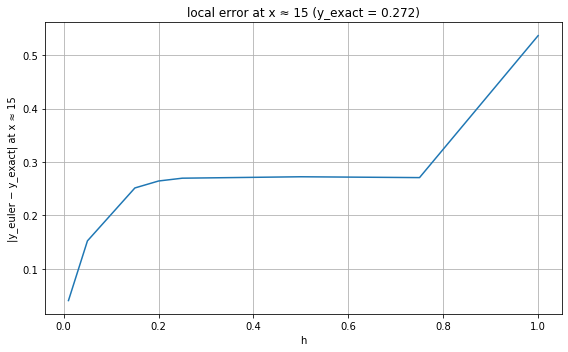

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# exact solution
def exact(x):
    return np.exp(-2 * np.sin(x))

# euler's
def euler(h):
    xs = np.arange(0, 10 * np.pi + h, h)
    ys = np.zeros(len(xs))
    ys[0] = 1.0
    for i in range(1, len(xs)):
        ys[i] = ys[i-1] + h * (-2 * ys[i-1] * np.cos(xs[i-1]))
    return xs, ys

h_values = [0.01, 0.05, 0.15, 0.20, 0.25, 0.50, 0.75, 1.00]

results = {}
for h in h_values:
    xs, ys = euler(h)
    results[h] = (xs, ys)

# plot 1
fig1, ax1 = plt.subplots(figsize=(12, 5))

x_exact = np.linspace(0, 10 * np.pi, 5000)
ax1.plot(x_exact, exact(x_exact), label='Exact')

for h, (xs, ys) in results.items():
    ax1.plot(xs, ys, label=f'h = {h}')

ax1.set_title("euler's solution curves")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend()
ax1.grid()
plt.tight_layout()
plt.show()

# plot 2
avg_errors = []
for h in h_values:
    xs, ys = results[h]
    ye = exact(xs)
    avg_errors.append(np.mean(np.abs(ys - ye)))

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(h_values, avg_errors)
ax2.set_title("avg global error")
ax2.set_xlabel("h")
ax2.set_ylabel("mean |y_euler − y_exact|")
ax2.grid()
plt.tight_layout()
plt.show()

# plot 3
local_errors = []
y_at_15 = []
target_x = 15.0
y_exact_15 = exact(target_x)

for h in h_values:
    xs, ys = results[h]
    idx = np.argmin(np.abs(xs - target_x))
    x_close = xs[idx]
    y_euler  = ys[idx]
    y_true   = exact(x_close)
    local_errors.append(abs(y_euler - y_true))
    y_at_15.append((x_close, y_euler, y_true))

fig3, ax3 = plt.subplots(figsize=(8, 5))
ax3.plot(h_values, local_errors)

ax3.set_title(f"local error at x ≈ 15 (y_exact = {y_exact_15:.3f})")
ax3.set_xlabel("h")
ax3.set_ylabel("|y_euler − y_exact| at x ≈ 15")
ax3.grid()
plt.tight_layout()
plt.show()

## The exact solution oscillates perfectly because, well, it's the exact solution. Small step sizes h can replicate 
## it relatively accurately and smoothly, but as h grows, errors begin compounding, breaking down the approximation.
## For a long interval such as [0, 10pi], Euler's Method requires a small h value to remain accurate.